In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [165]:
df = pd.read_csv("finally.csv")

In [166]:
df.head()

,CUSTOMER_ID,TOTAL_SPENDING,FREQUENCY,RETURN_RATIO,TOP_CATEGORY,Recency,AVG_ORDER_VALUE,PURCHASE_INTENSITY,AVG_PURCHASE_GAP,ONE_TIME_CUSTOMER
0,12747,50694.15,11,0.068063,Sports,2,265.414398,17.363636,36.300000,0
1,12748,1514026.80,208,0.064956,Stationery,1,184.165771,39.524038,1.382488,0
2,12749,146544.45,7,0.054863,Beauty,4,365.447506,57.285714,29.428571,0
3,12820,11971.70,4,0.072289,Sports,3,144.237349,20.750000,107.333333,0
4,12821,1374.10,1,0.000000,Beauty,214,343.525000,4.000000,45.000000,1


<Axes: >

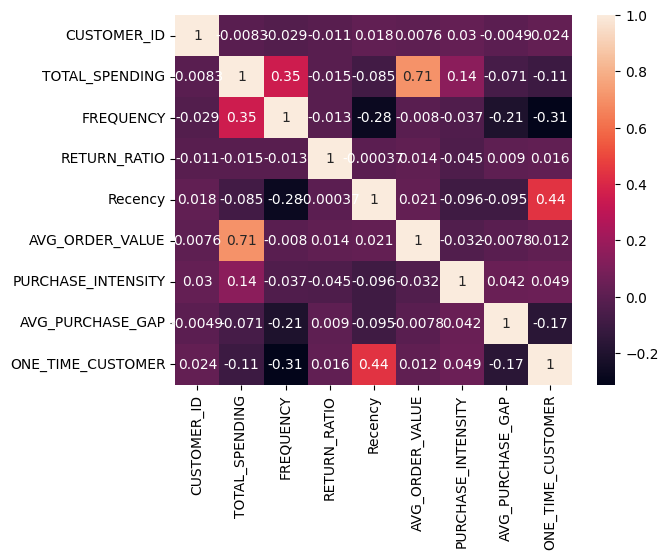

In [167]:
sns.heatmap(df.corr(numeric_only = True),annot = True)

<Axes: xlabel='AVG_PURCHASE_GAP', ylabel='Count'>

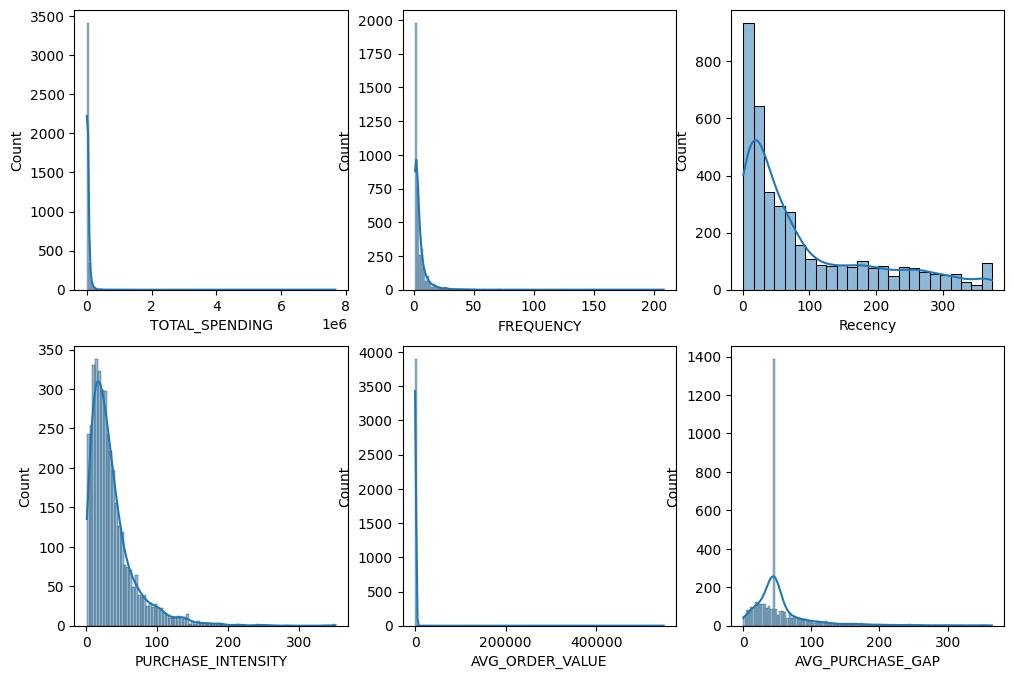

In [168]:
plt.figure(figsize=(12, 8))
plt.subplot(2,3,1)
sns.histplot(df["TOTAL_SPENDING"], kde = True)
plt.subplot(2,3,2)
sns.histplot(df["FREQUENCY"],kde = True)
plt.subplot(2,3,3)
sns.histplot(df["Recency"],kde = True)
plt.subplot(2,3,4) 
sns.histplot(df["PURCHASE_INTENSITY"],kde = True)
plt.subplot(2,3,5)
sns.histplot(df["AVG_ORDER_VALUE"],kde = True)
plt.subplot(2,3,6)
sns.histplot(df["AVG_PURCHASE_GAP"],kde = True)


In [169]:
df1 = df.copy()
df2 = df.copy()
df3 = df.copy()
df4 = df.copy()

In [170]:
import numpy as np

cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'PURCHASE_INTENSITY',
    'AVG_ORDER_VALUE',
    'AVG_PURCHASE_GAP'
]

for col in cols:
    lower = df1[col].quantile(0.01)   
    upper = df1[col].quantile(0.99)  

    df1[col] = np.where(df1[col] < lower, lower, df1[col])
    df1[col] = np.where(df1[col] > upper, upper, df1[col])

<Axes: xlabel='AVG_PURCHASE_GAP', ylabel='Count'>

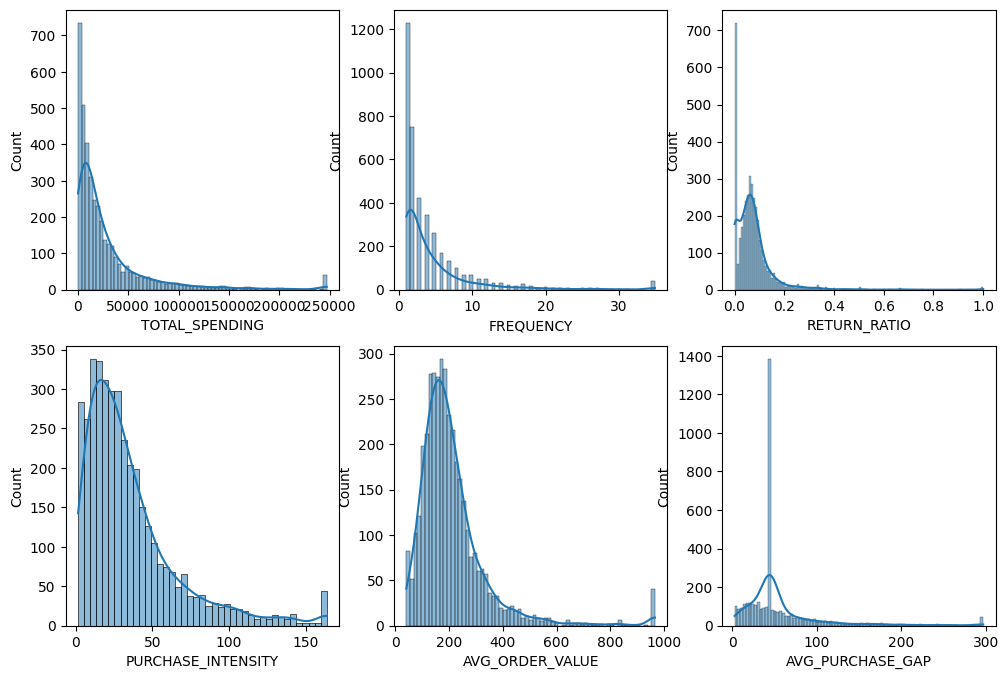

In [171]:
plt.figure(figsize=(12, 8))
plt.subplot(2,3,1)
sns.histplot(df1["TOTAL_SPENDING"], kde = True)
plt.subplot(2,3,2)
sns.histplot(df1["FREQUENCY"],kde = True)
plt.subplot(2,3,3)
sns.histplot(df1["RETURN_RATIO"],kde = True)
plt.subplot(2,3,4)
sns.histplot(df1["PURCHASE_INTENSITY"],kde = True)
plt.subplot(2,3,5)
sns.histplot(df1["AVG_ORDER_VALUE"],kde = True)
plt.subplot(2,3,6)
sns.histplot(df1["AVG_PURCHASE_GAP"],kde = True)

In [172]:
import numpy as np

cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'PURCHASE_INTENSITY',
    'AVG_ORDER_VALUE',
    'AVG_PURCHASE_GAP'
]

for col in cols:
    df2[col] = np.sqrt(df2[col])

<Axes: xlabel='AVG_PURCHASE_GAP', ylabel='Count'>

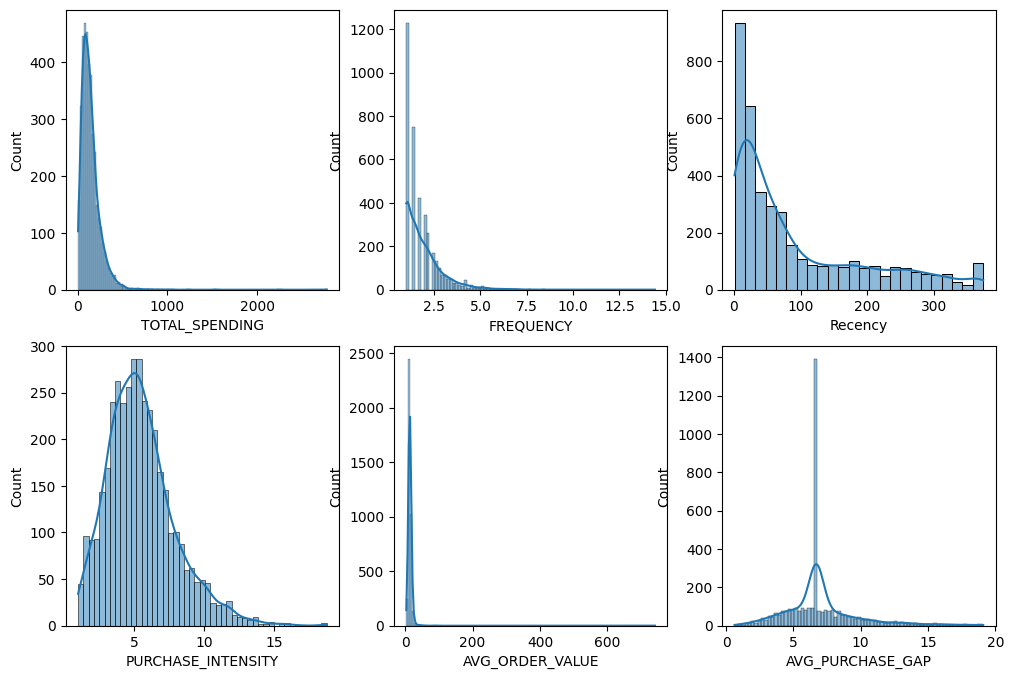

In [173]:
plt.figure(figsize=(12, 8))
plt.subplot(2,3,1)
sns.histplot(df2["TOTAL_SPENDING"], kde = True)
plt.subplot(2,3,2)
sns.histplot(df2["FREQUENCY"],kde = True)
plt.subplot(2,3,3)
sns.histplot(df2["Recency"],kde = True)
plt.subplot(2,3,4)
sns.histplot(df2["PURCHASE_INTENSITY"],kde = True)
plt.subplot(2,3,5)
sns.histplot(df2["AVG_ORDER_VALUE"],kde = True)
plt.subplot(2,3,6)
sns.histplot(df2["AVG_PURCHASE_GAP"],kde = True)

In [174]:
import numpy as np

cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'PURCHASE_INTENSITY',
    'AVG_ORDER_VALUE',
    'AVG_PURCHASE_GAP'
]

for col in cols:
    lower = df3[col].quantile(0.01)   
    upper = df3[col].quantile(0.99)  

    df3[col] = np.where(df3[col] < lower, lower, df3[col])
    df3[col] = np.where(df3[col] > upper, upper, df3[col])

In [175]:
import numpy as np

cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'PURCHASE_INTENSITY',
    'AVG_ORDER_VALUE',
    'AVG_PURCHASE_GAP'
]

for col in cols:
    df3[col] = np.sqrt(df3[col])

In [176]:
import numpy as np


cap_cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'AVG_ORDER_VALUE'
]

for col in cap_cols:
    upper = df4[col].quantile(0.99)
    df4[col] = np.where(df4[col] > upper, upper, df4[col])


sqrt_cols = [
    'PURCHASE_INTENSITY',
    'AVG_PURCHASE_GAP'
]

for col in sqrt_cols:
    df4[col] = np.sqrt(df4[col])

<Axes: xlabel='AVG_PURCHASE_GAP', ylabel='Count'>

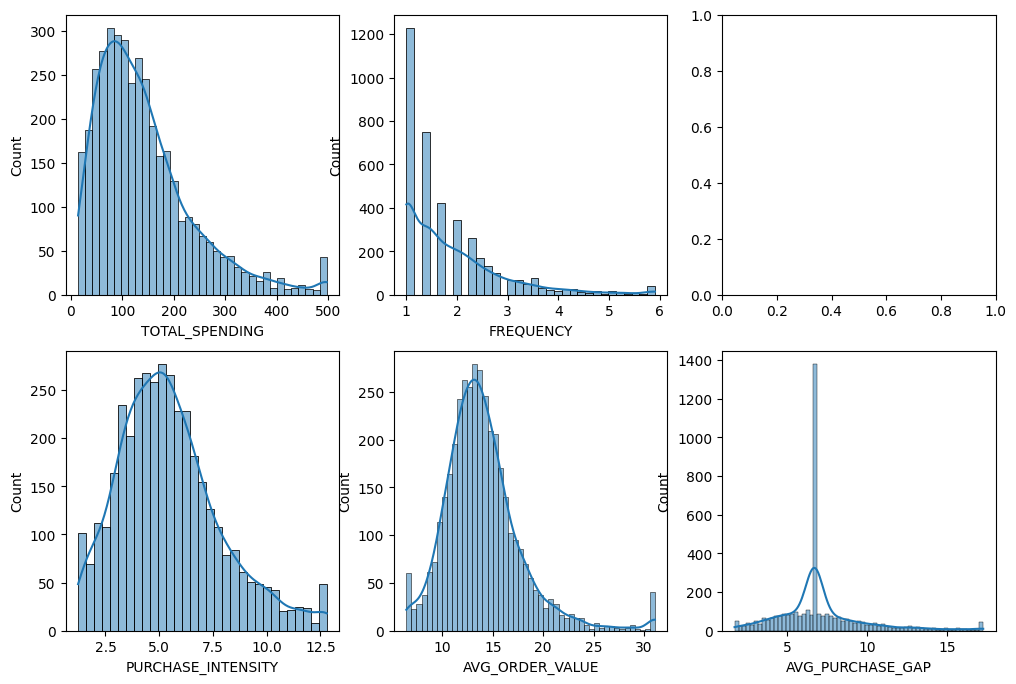

In [177]:
plt.figure(figsize=(12, 8))
plt.subplot(2,3,1)
sns.histplot(df3["TOTAL_SPENDING"], kde = True)
plt.subplot(2,3,2)
sns.histplot(df3["FREQUENCY"],kde = True)
plt.subplot(2,3,3)
# sns.histplot(df2["RETURN_RATIO"],kde = True)
plt.subplot(2,3,4)
sns.histplot(df3["PURCHASE_INTENSITY"],kde = True)
plt.subplot(2,3,5)
sns.histplot(df3["AVG_ORDER_VALUE"],kde = True)
plt.subplot(2,3,6)
sns.histplot(df3["AVG_PURCHASE_GAP"],kde = True)

In [178]:
features = ['TOTAL_SPENDING', 'FREQUENCY', 'RETURN_RATIO', 'AVG_ORDER_VALUE',"Recency"]

In [179]:
X = df[features]
X1 = df1[features]
X2 = df2[features]
X3 = df3[features]
X4 = df4[features]

In [180]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled1 = scaler.fit_transform(X1)
X_scaled2= scaler.fit_transform(X2)
X_scaled3 = scaler.fit_transform(X3)
X_scaled4 = scaler.fit_transform(X4)

In [181]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [182]:
wcss1 = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled1)
    wcss1.append(kmeans.inertia_)

In [183]:
wcss2 = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled2)
    wcss2.append(kmeans.inertia_)

In [184]:
wcss3 = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled3)
    wcss3.append(kmeans.inertia_)

In [185]:
wcss4 = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled4)
    wcss4.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

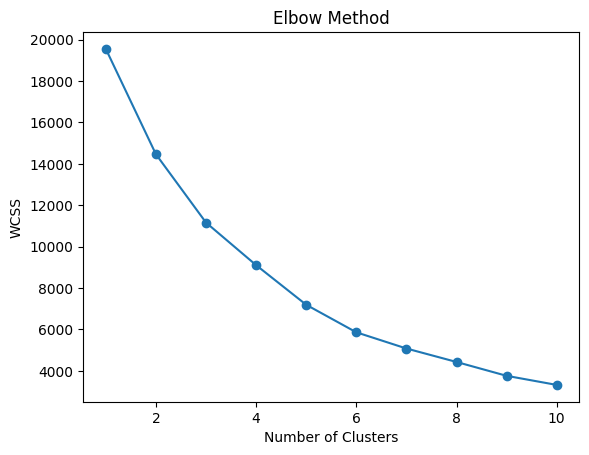

In [186]:

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")




Text(0, 0.5, 'WCSS')

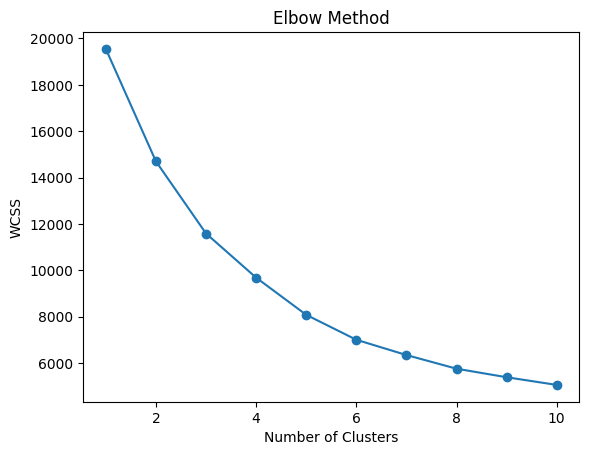

In [187]:
plt.figure()
plt.plot(range(1, 11), wcss1, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")


In [188]:
k = 4  

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df1['Cluster'] = kmeans.fit_predict(X_scaled1)


In [189]:
score = silhouette_score(X_scaled1, df1['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.3660964502729388


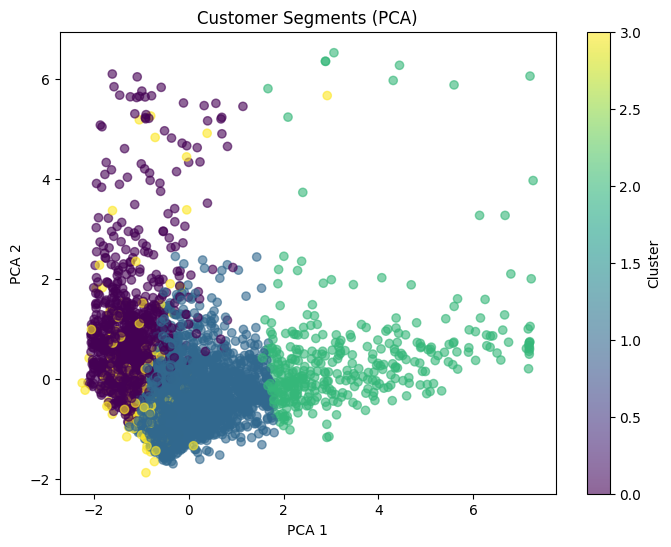

In [190]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled1)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df1['Cluster'], cmap='viridis', alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA)")

plt.colorbar(label='Cluster')
plt.show()

In [191]:
cluster_summary = df1.groupby('Cluster')[features].mean()

print("\nCluster Summary:\n")
print(cluster_summary)


Cluster Summary:

         TOTAL_SPENDING  FREQUENCY  RETURN_RATIO  AVG_ORDER_VALUE     Recency
Cluster                                                                      
0          11582.620953   1.717295      0.047301       272.249522  242.200665
1          22317.317898   3.771866      0.063827       185.228553   44.632003
2         128203.308840  17.716164      0.070209       233.390460   17.783562
3           6660.468910   1.580247      0.363184       228.121679  143.228395


Text(0, 0.5, 'WCSS')

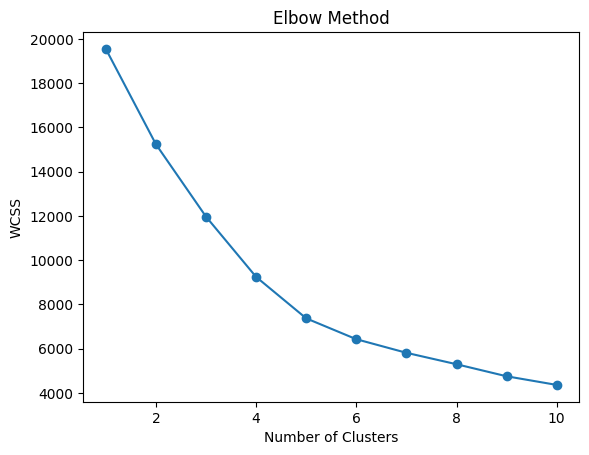

In [192]:
plt.figure()
plt.plot(range(1, 11), wcss2, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")


In [193]:
k = 3  
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df2['Cluster'] = kmeans.fit_predict(X_scaled2)


In [194]:
score = silhouette_score(X_scaled2, df2['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.2903904697727673


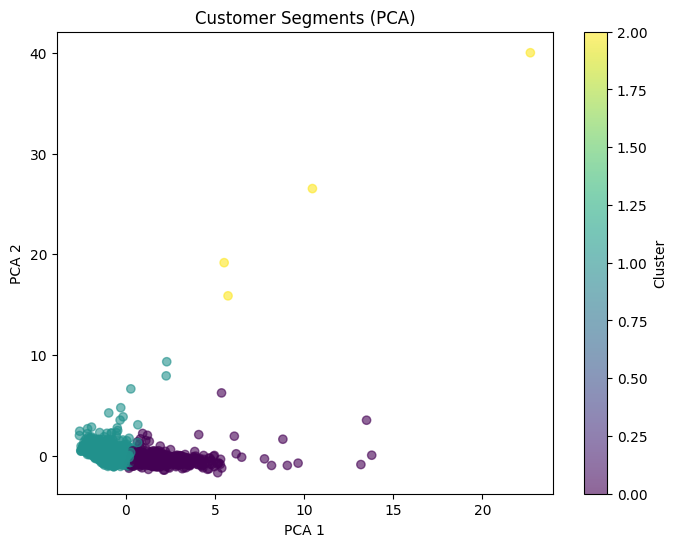

In [195]:
pca = PCA(n_components=2)
X_pca1 = pca.fit_transform(X_scaled2)

plt.figure(figsize=(8,6))
plt.scatter(X_pca1[:, 0], X_pca1[:, 1], c=df2['Cluster'], cmap='viridis', alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA)")

plt.colorbar(label='Cluster')
plt.show()

In [196]:
cluster_summary = df2.groupby('Cluster')[features].mean()

print("\nCluster Summary:\n")
print(cluster_summary)


Cluster Summary:

         TOTAL_SPENDING  FREQUENCY  RETURN_RATIO  AVG_ORDER_VALUE     Recency
Cluster                                                                      
0            241.521892   2.970096      0.069174        14.346484   25.616139
1             92.790435   1.334392      0.074712        14.196486  125.724031
2           1246.463192   1.250000      0.250000       488.536045  139.000000


Text(0, 0.5, 'WCSS')

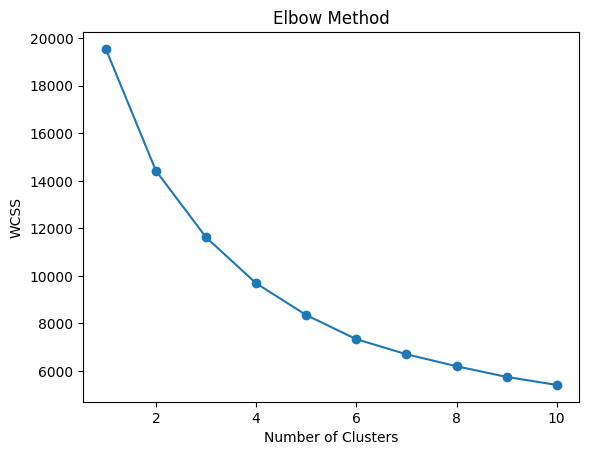

In [197]:
plt.figure()
plt.plot(range(1, 11), wcss3, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

In [198]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df3['Cluster'] = kmeans.fit_predict(X_scaled3)


In [199]:
score = silhouette_score(X_scaled3, df3['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.2866319383603065


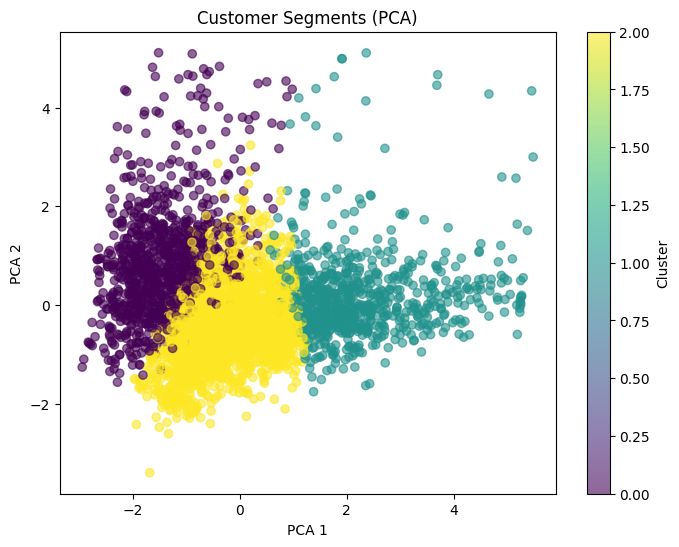

In [200]:
pca = PCA(n_components=2)
X_pca2 = pca.fit_transform(X_scaled3)

plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=df3['Cluster'], cmap='viridis', alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA)")

plt.colorbar(label='Cluster')
plt.show()

In [201]:
cluster_summary = df3.groupby('Cluster')[features].mean()

print("\nCluster Summary:\n")
print(cluster_summary)


Cluster Summary:

         TOTAL_SPENDING  FREQUENCY  RETURN_RATIO  AVG_ORDER_VALUE     Recency
Cluster                                                                      
0             89.075719   1.217515      0.069406        15.638363  247.069339
1            289.543662   3.448291      0.071366        14.776956   25.639300
2            114.398351   1.621149      0.075043        13.096356   49.819964


Text(0, 0.5, 'WCSS')

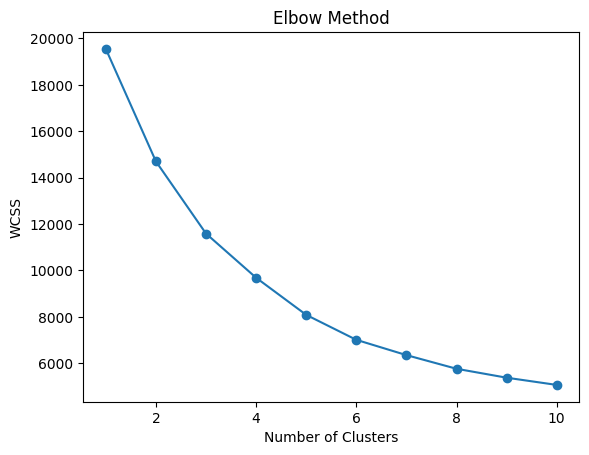

In [202]:
plt.figure()
plt.plot(range(1, 11), wcss4, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")


In [203]:
k = 4 

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df4['Cluster'] = kmeans.fit_predict(X_scaled4)


In [204]:
score = silhouette_score(X_scaled4, df4['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.36596755968331324


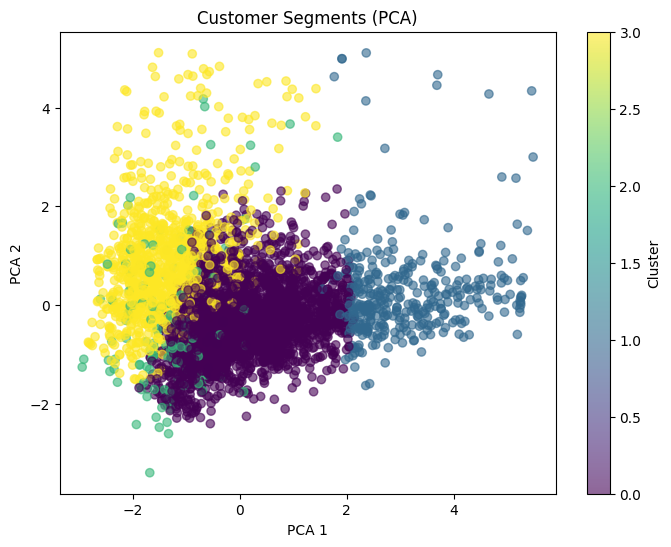

In [205]:
pca = PCA(n_components=2)
X_pca3 = pca.fit_transform(X_scaled3)

plt.figure(figsize=(8,6))
plt.scatter(X_pca3[:, 0], X_pca3[:, 1], c=df4['Cluster'], cmap='viridis', alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA)")

plt.colorbar(label='Cluster')
plt.show()

In [206]:
cluster_summary = df3.groupby('Cluster')[features].mean()

print("\nCluster Summary:\n")
print(cluster_summary)


Cluster Summary:

         TOTAL_SPENDING  FREQUENCY  RETURN_RATIO  AVG_ORDER_VALUE     Recency
Cluster                                                                      
0             89.075719   1.217515      0.069406        15.638363  247.069339
1            289.543662   3.448291      0.071366        14.776956   25.639300
2            114.398351   1.621149      0.075043        13.096356   49.819964
